# Causal Trees/Forests Treatment Effects Estimation and Tree Visualization

In [1]:
import pandas as pd
import numpy as np
import multiprocessing as mp
from collections import defaultdict

np.random.seed(42)

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor

import causalml
from causalml.metrics import plot_gain, plot_qini, qini_score
from causalml.dataset import synthetic_data
from causalml.inference.tree import plot_dist_tree_leaves_values, get_tree_leaves_mask
from causalml.inference.meta import BaseSRegressor, BaseXRegressor, BaseTRegressor, BaseDRRegressor
from causalml.inference.tree import CausalRandomForestRegressor
from causalml.inference.tree import CausalTreeRegressor
from causalml.inference.tree.plot import plot_causal_tree

import matplotlib.pyplot as plt
import seaborn as sns

%config InlineBackend.figure_format = 'retina'

Failed to import duecredit due to No module named 'duecredit'


In [2]:
import importlib
print(importlib.metadata.version('causalml') )

0.15.1


In [3]:
# Simulate randomized trial: mode=2
y, X, w, tau, b, e = synthetic_data(mode=2, n=15000, p=20, sigma=5.5)

df = pd.DataFrame(X)
feature_names = [f'feature_{i}' for i in range(X.shape[1])]
df.columns = feature_names
df['outcome'] = y
df['treatment'] = w
df['treatment_effect'] = tau

In [4]:
df

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,...,feature_13,feature_14,feature_15,feature_16,feature_17,feature_18,feature_19,outcome,treatment,treatment_effect
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,...,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,7.413595,1,1.123117
1,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,...,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861,-11.263144,0,2.052266
2,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,...,0.611676,1.031000,0.931280,-0.839218,-0.309212,0.331263,0.975545,0.269378,0,1.520964
3,-0.479174,-0.185659,-1.106335,-1.196207,0.812526,1.356240,-0.072010,1.003533,0.361636,-0.645120,...,1.564644,-2.619745,0.821903,0.087047,-0.299007,0.091761,-1.987569,-0.976893,0,0.125446
4,-0.219672,0.357113,1.477894,-0.518270,-0.808494,-0.501757,0.915402,0.328751,-0.529760,0.513267,...,-0.327662,-0.392108,-1.463515,0.296120,0.261055,0.005113,-0.234587,-0.608710,1,0.667889
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,-0.477187,0.975080,-0.903032,0.115963,-0.764867,-0.306861,0.933770,-0.423353,0.617239,1.009146,...,1.501011,0.021374,1.360836,0.815518,0.405290,-0.168378,-0.331695,-6.877430,0,0.817918
14996,2.341515,-1.466627,1.937957,-0.477542,0.535959,0.246006,-0.080677,-1.435310,-0.766971,-0.806781,...,0.645807,0.647226,1.328996,-0.504029,-0.550762,-0.776301,0.987144,13.373485,1,2.549100
14997,0.549791,0.153801,-1.777971,-0.364424,-0.209354,0.554411,-0.482307,0.993510,0.078060,-0.158675,...,-0.893470,-1.546876,0.146677,1.103348,-0.880958,0.667706,0.522392,2.671879,0,1.322792
14998,-0.178341,0.684063,1.022725,-0.089178,-0.417637,0.657545,-1.215015,0.800834,1.336592,-0.425979,...,0.886550,-0.316745,1.847580,-0.395809,-1.109346,-0.608961,-0.522697,2.137853,0,0.914224


In [5]:
# Look at the conversion rate and sample size in each group
df.pivot_table(values='outcome',
               index='treatment',
               aggfunc=[np.mean, np.size],
               margins=True)

,mean,size
,outcome,outcome
treatment,,
0,0.994413,7502
1,1.802171,7498
All,1.398184,15000


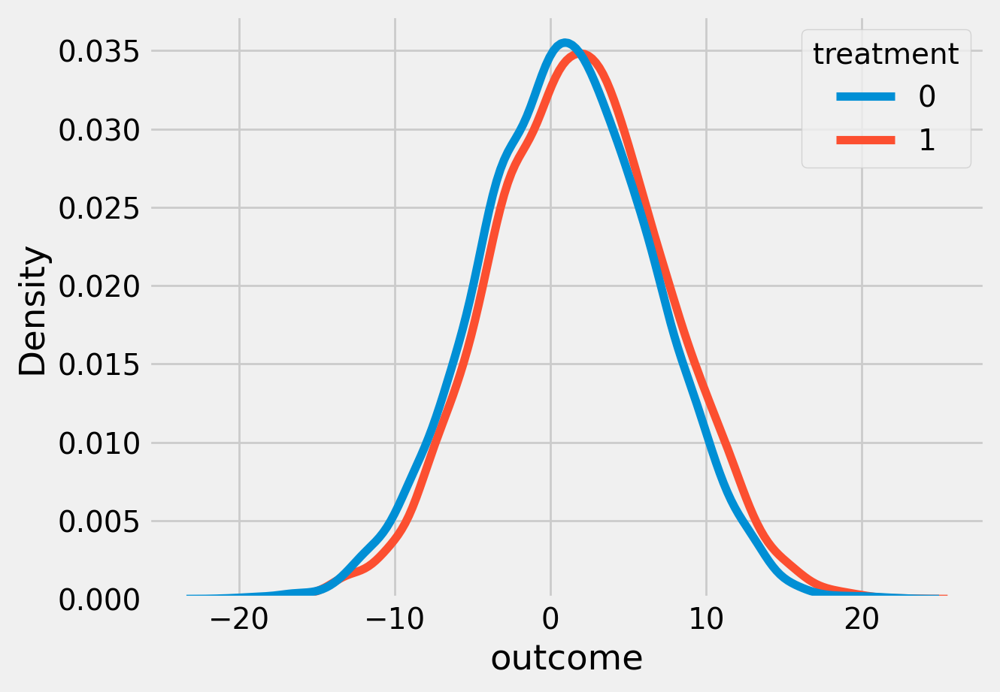

In [6]:
sns.kdeplot(data=df, x='outcome', hue='treatment')
plt.show()

In [7]:
# Split data to training and testing samples for model validation (next section)
df_train, df_test = train_test_split(df, test_size=0.2, random_state=11101)
n_test = df_test.shape[0]
n_train = df_train.shape[0]

In [8]:
# Table to gather estimated ITEs by models
df_result = pd.DataFrame({
    'outcome': df_test['outcome'],
    'is_treated': df_test['treatment'],
    'treatment_effect': df_test['treatment_effect']
})

### CausalTreeRegressor

Available criteria for causal trees:

`standard_mse`: scikit-learn MSE where node values store $E_{node_i}(X|T=1)-E_{node_i}(X|T=0)$, treatment effects.

`causal_mse`: *The criteria reward a partition for finding strong heterogeneity in treatment effects and penalize a partition that creates variance in leaf estimates.*
https://www.pnas.org/doi/10.1073/pnas.1510489113

In [9]:
ctrees = {
    'ctree_mse': {
        'params':
        dict(criterion='standard_mse',
             control_name=0,
             min_impurity_decrease=0,
             min_samples_leaf=400,
             groups_penalty=0.,
             groups_cnt=True),
    },
    'ctree_cmse': {
        'params':
        dict(
            criterion='causal_mse',
            control_name=0,
            min_samples_leaf=400,
            groups_penalty=0.,
            groups_cnt=True,
        ),
    },
    'ctree_cmse_p=0.1': {
        'params':
        dict(
            criterion='causal_mse',
            control_name=0,
            min_samples_leaf=400,
            groups_penalty=0.1,
            groups_cnt=True,
        ),
    },
    'ctree_cmse_p=0.25': {
        'params':
        dict(
            criterion='causal_mse',
            control_name=0,
            min_samples_leaf=400,
            groups_penalty=0.25,
            groups_cnt=True,
        ),
    },
    'ctree_cmse_p=0.5': {
        'params':
        dict(
            criterion='causal_mse',
            control_name=0,
            min_samples_leaf=400,
            groups_penalty=0.5,
            groups_cnt=True,
        ),
    },
    'ctree_ttest': {
        'params':
        dict(criterion='t_test',
             control_name=0,
             min_samples_leaf=400,
             groups_penalty=0.,
             groups_cnt=True),
    },
}

In [10]:
%%time
# Model treatment effect
for ctree_name, ctree_info in ctrees.items():
    print(f"Fitting: {ctree_name}")
    ctree = CausalTreeRegressor(**ctree_info['params'])
    ctree.fit(X=df_train[feature_names].values,
              treatment=df_train['treatment'].values,
              y=df_train['outcome'].values)
    
    ctrees[ctree_name].update({'model': ctree})
    df_result[ctree_name] = ctree.predict(df_test[feature_names].values)

Fitting: ctree_mse
Fitting: ctree_cmse
Fitting: ctree_cmse_p=0.1
Fitting: ctree_cmse_p=0.25
Fitting: ctree_cmse_p=0.5
Fitting: ctree_ttest
CPU times: user 1.29 s, sys: 7.36 ms, total: 1.3 s
Wall time: 1.31 s


In [11]:
df_result.head()

,outcome,is_treated,treatment_effect,ctree_mse,ctree_cmse,ctree_cmse_p=0.1,ctree_cmse_p=0.25,ctree_cmse_p=0.5,ctree_ttest
625,3.519424,1,0.819201,1.624443,-1.690532,0.129960,-0.947096,-0.947096,-1.690532
5717,-0.456031,0,1.131599,0.809237,0.367659,0.992395,1.978697,1.978697,1.054970
14801,4.479222,0,1.969727,1.624443,-0.778434,3.388318,1.937710,1.937710,1.744661
13605,4.523891,0,0.884079,0.809237,0.367659,0.992395,0.805110,0.805110,1.039292
4208,-4.615111,0,1.179124,0.809237,2.134070,0.992395,0.928345,0.928345,1.054970


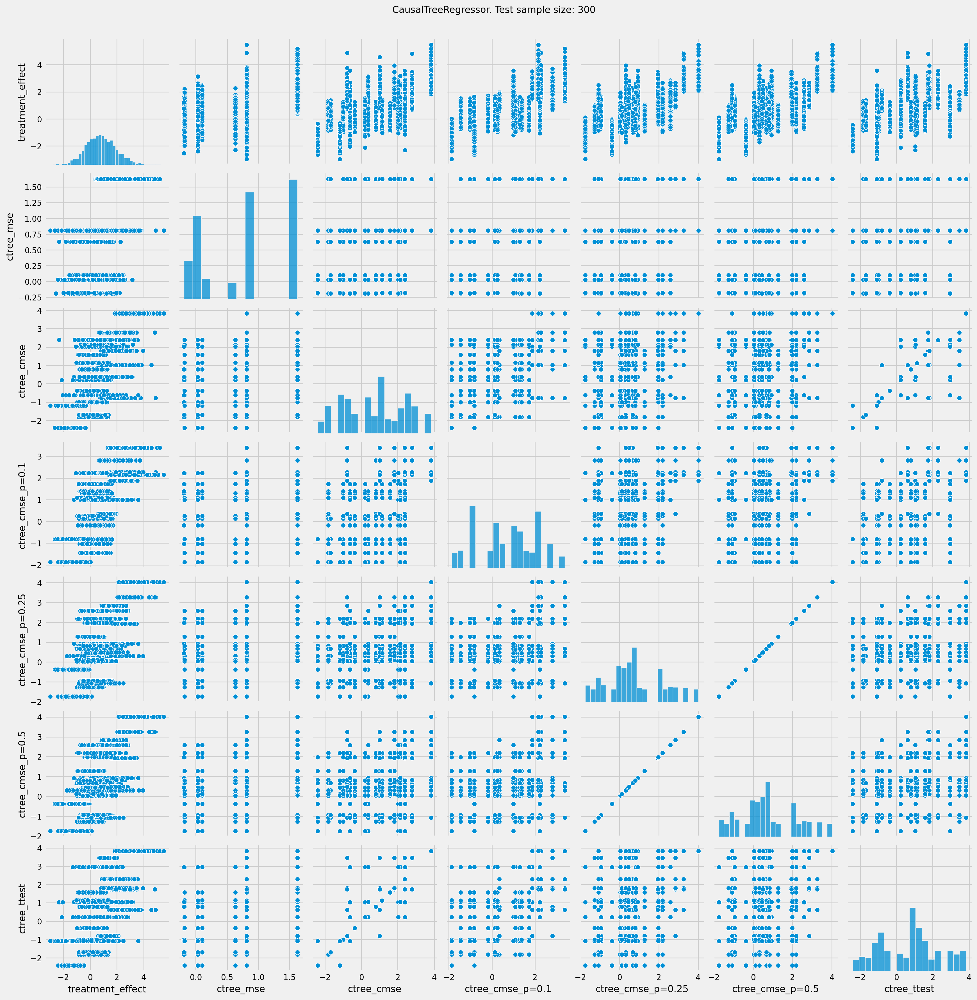

In [12]:
# See treatment effect estimation with CausalTreeRegressor vs true treatment effect

n_obs = 300

indxs = df_result.index.values
np.random.shuffle(indxs)
indxs = indxs[:n_obs]

plt.rcParams.update({'font.size': 10})
pairplot = sns.pairplot(df_result[['treatment_effect', *list(ctrees)]])
pairplot.fig.suptitle(f"CausalTreeRegressor. Test sample size: {n_obs}" , y=1.02)
plt.show()

#### Plot the Qini chart

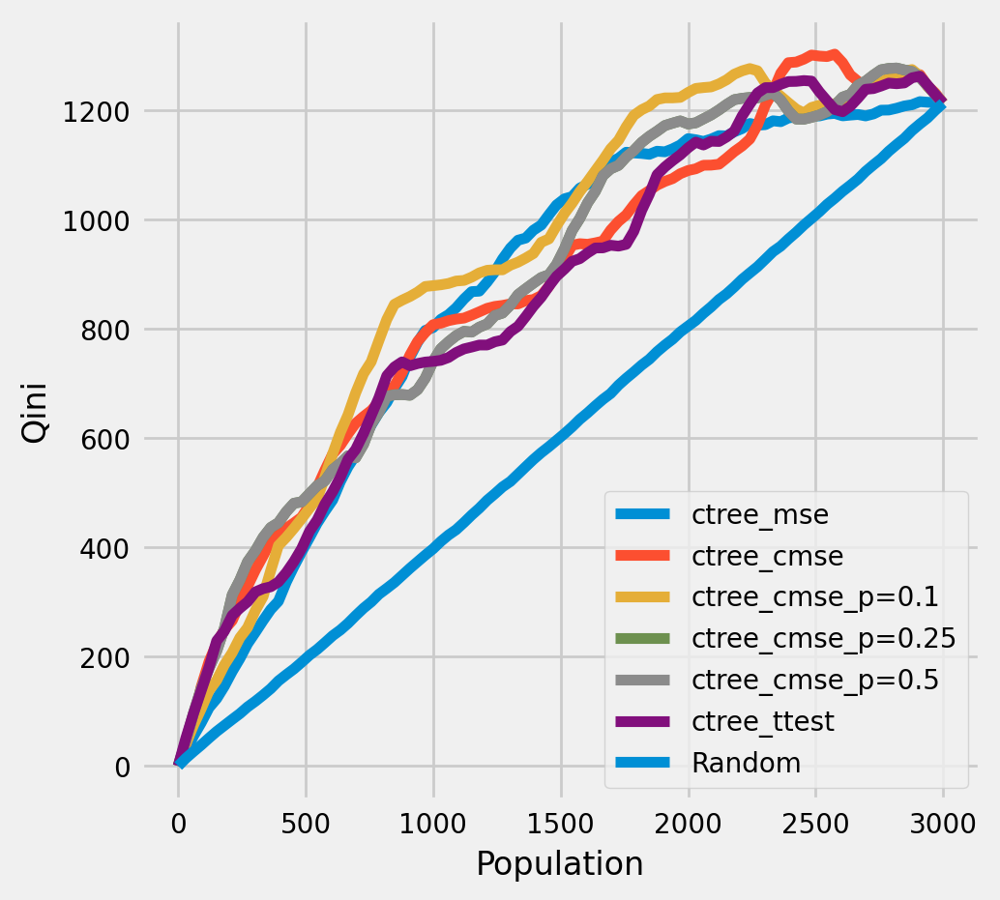

In [13]:
plot_qini(df_result,
          outcome_col='outcome',
          treatment_col='is_treated',
          treatment_effect_col='treatment_effect',
          figsize=(5,5)
         )

In [14]:
df_qini = qini_score(df_result,
           outcome_col='outcome',
           treatment_col='is_treated',
           treatment_effect_col='treatment_effect')
df_qini.sort_values(ascending=False)

ctree_cmse_p=0.1     0.259049
ctree_cmse_p=0.25    0.230985
ctree_cmse_p=0.5     0.230985
ctree_cmse           0.221881
ctree_mse            0.217035
ctree_ttest          0.204657
Random               0.000000
dtype: float64

#### The cumulative gain of the true treatment effect in each population

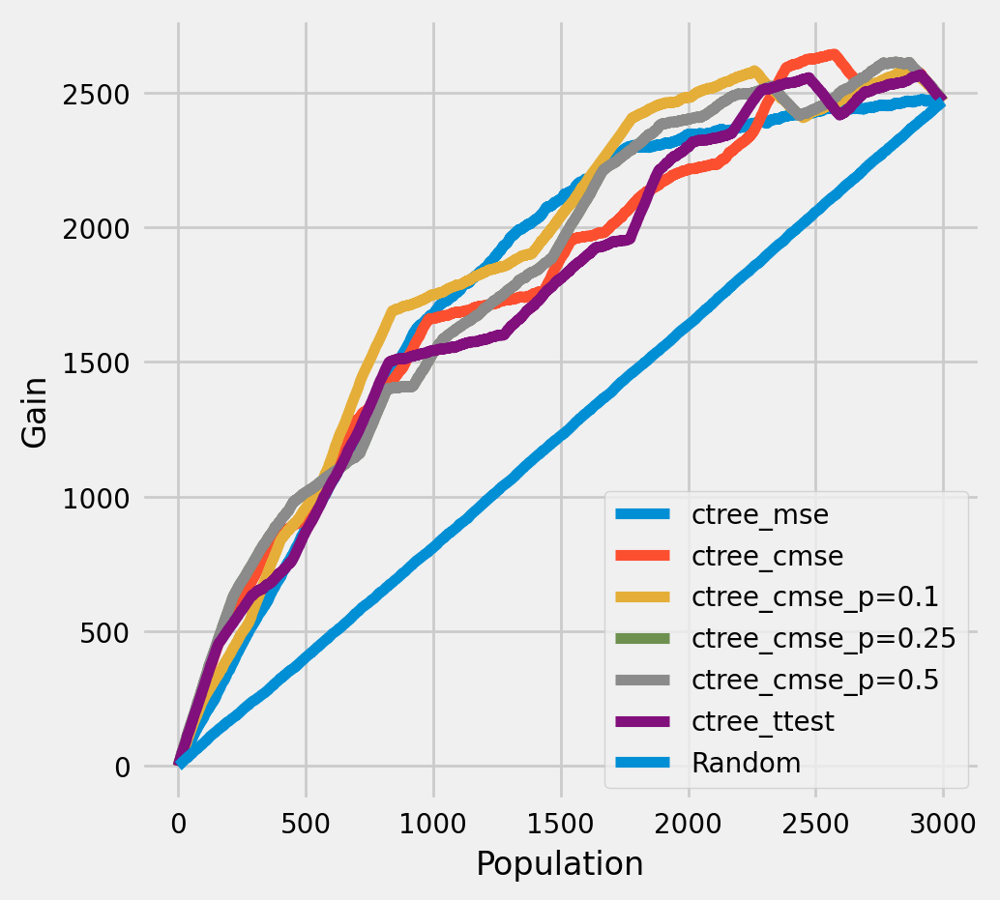

In [15]:
plot_gain(df_result, 
          outcome_col='outcome', 
          treatment_col='is_treated',
          treatment_effect_col='treatment_effect',
          n = n_test,
          figsize=(5,5)
         )

#### The cumulative difference between the mean outcomes of the treatment and control groups in each population

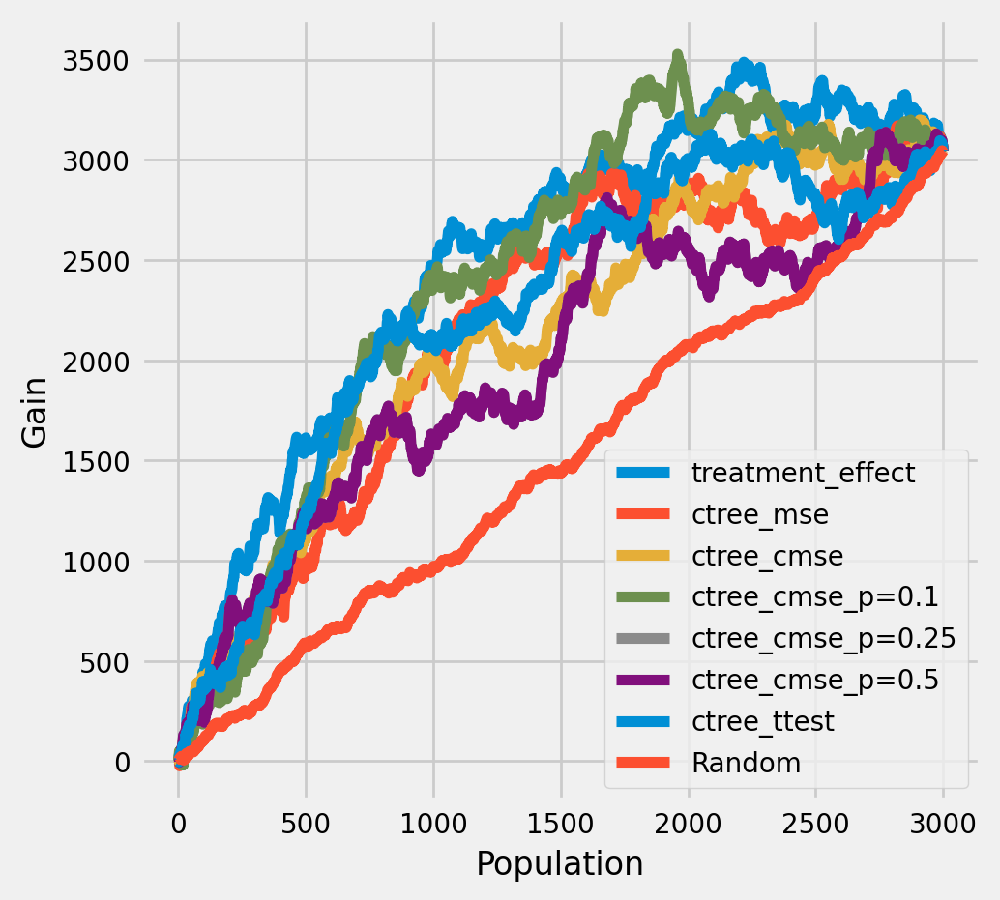

In [16]:
plot_gain(df_result, 
          outcome_col='outcome', 
          treatment_col='is_treated',
          n = n_test,
          figsize=(5,5)
         )

#### Plot trees with sklearn function and save as vector graphics

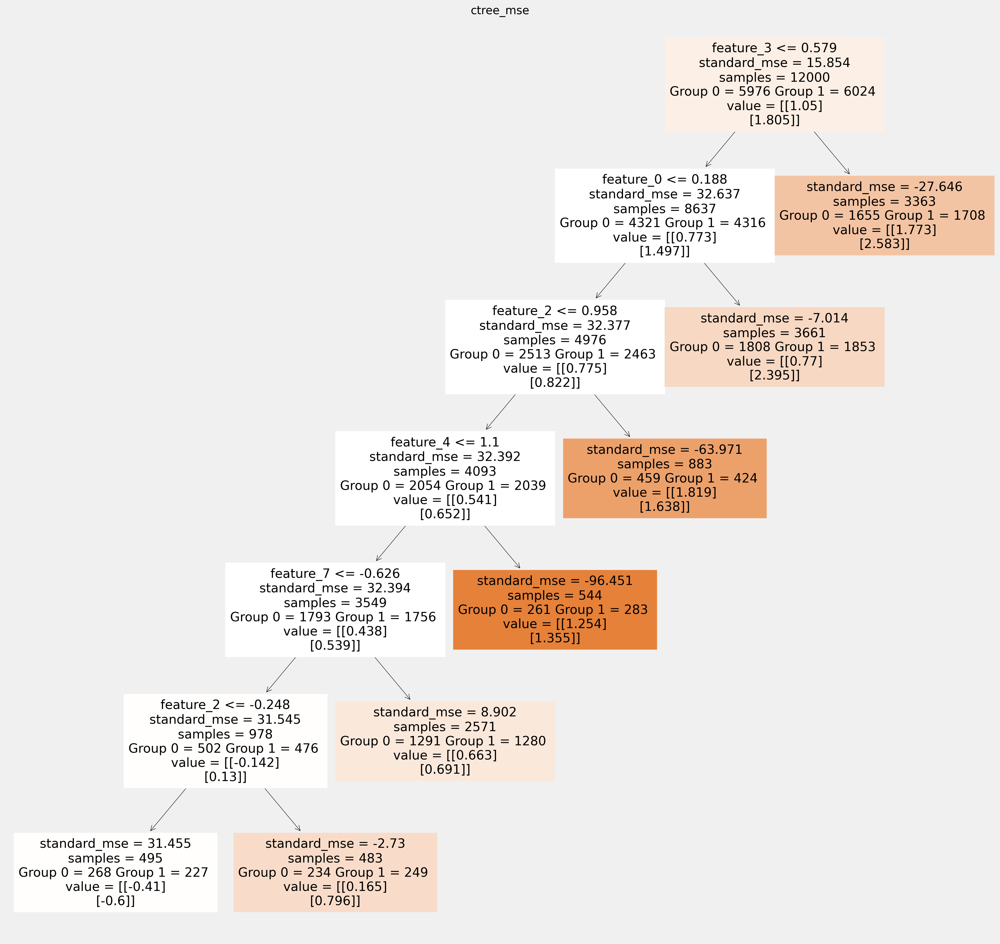

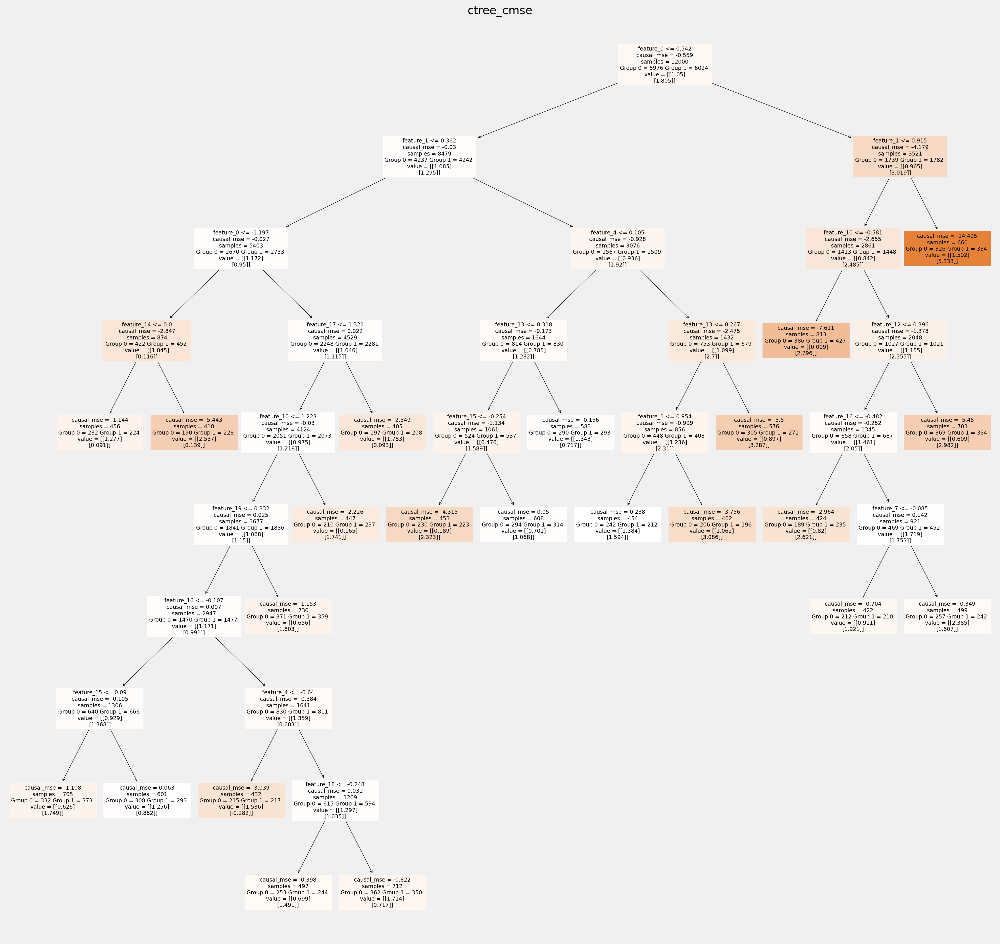

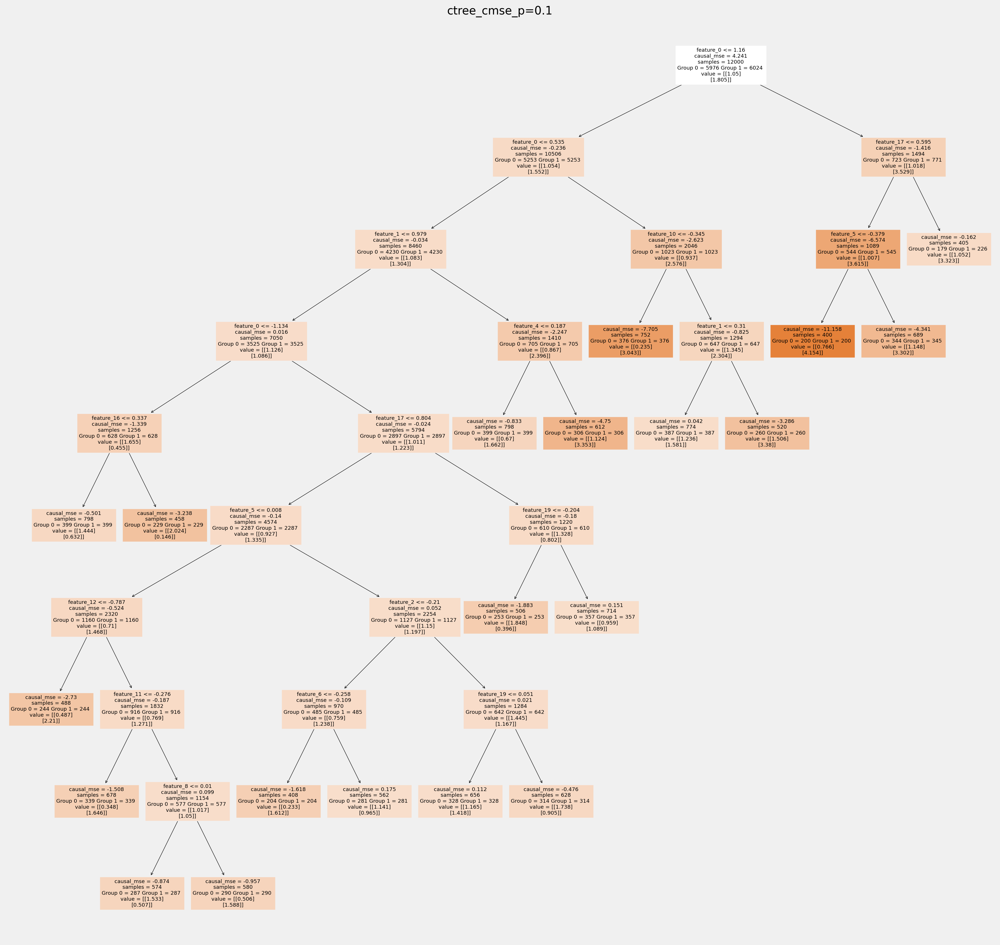

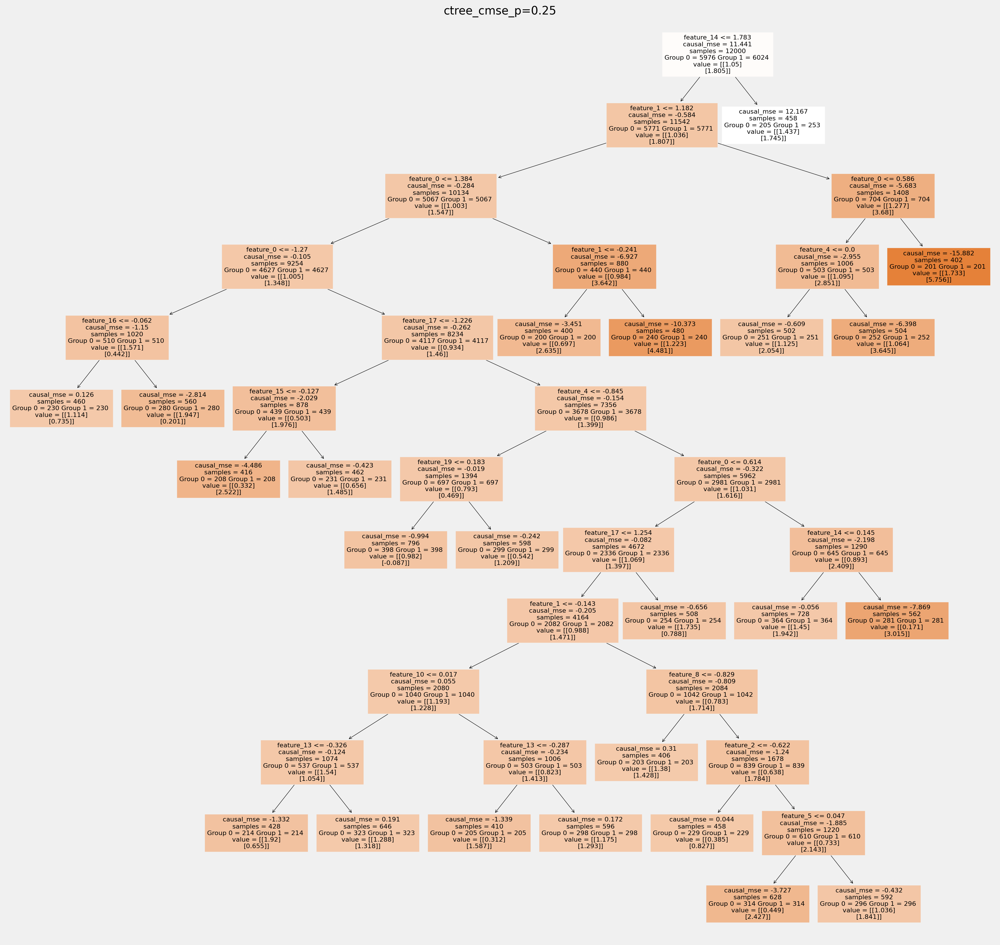

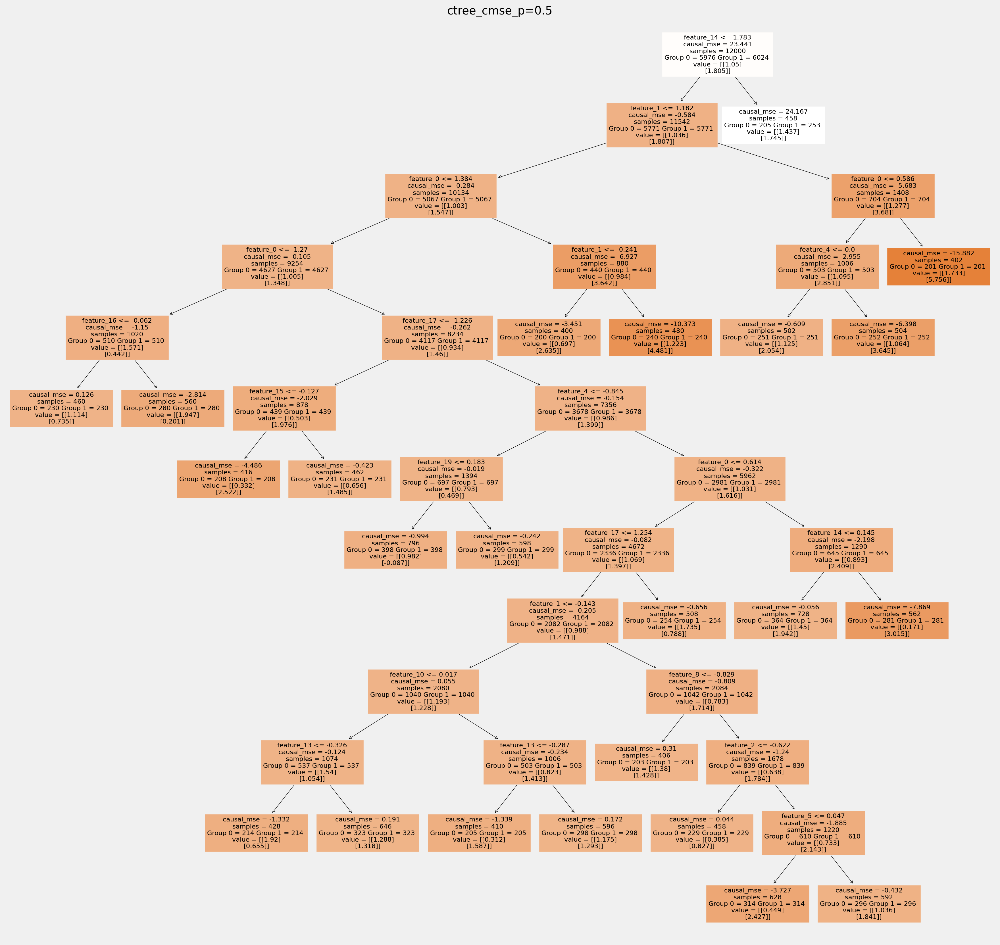

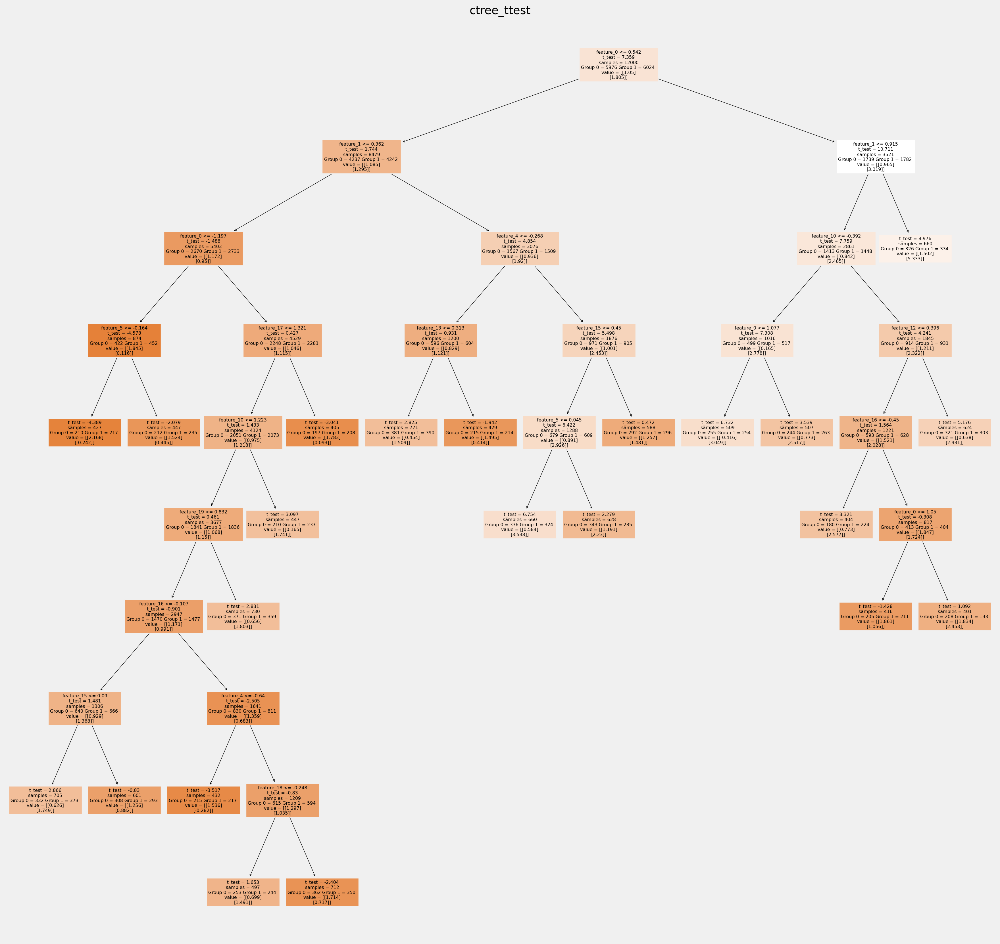

In [17]:
for ctree_name, ctree_info in ctrees.items():
    plt.figure(figsize=(20,20))
    plot_causal_tree(ctree_info['model'], 
                     feature_names = feature_names,
                     filled=True,
                     impurity=True,
                     proportion=False,
              )
    plt.title(ctree_name)
    plt.savefig(f'{ctree_name}.svg')

#### How values in leaves of the fitted trees differ from each other:

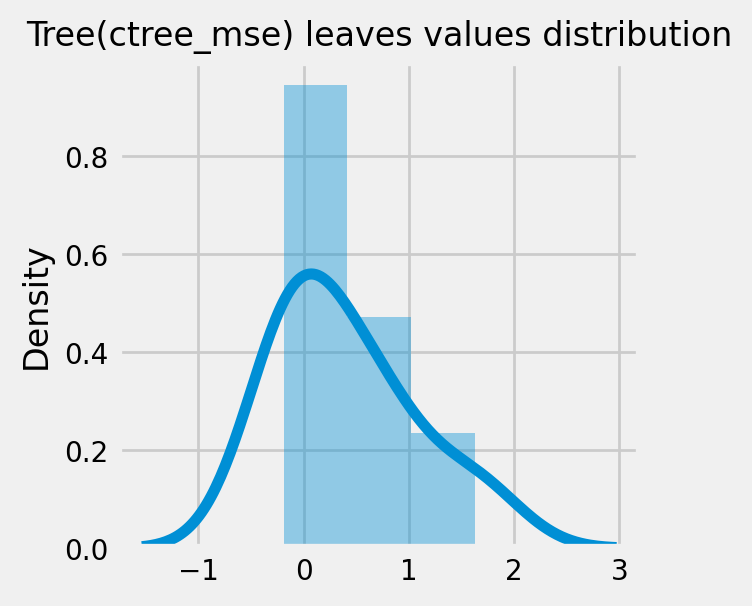

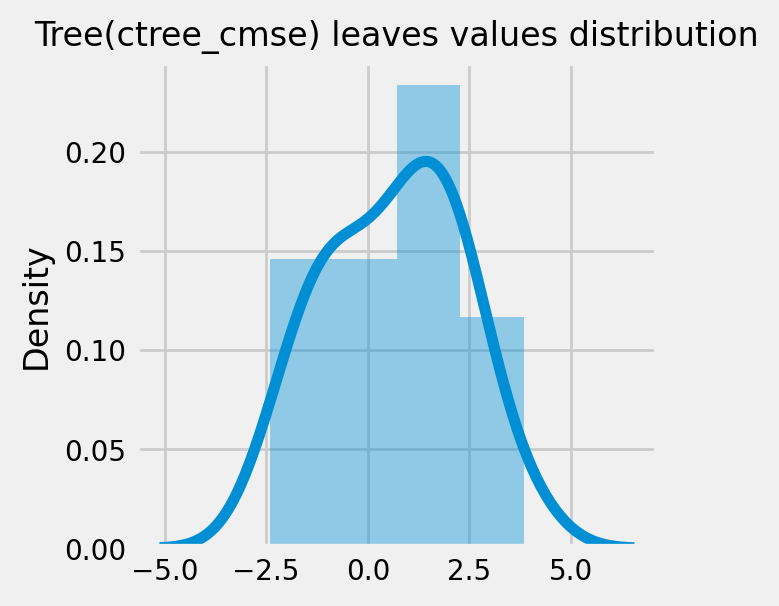

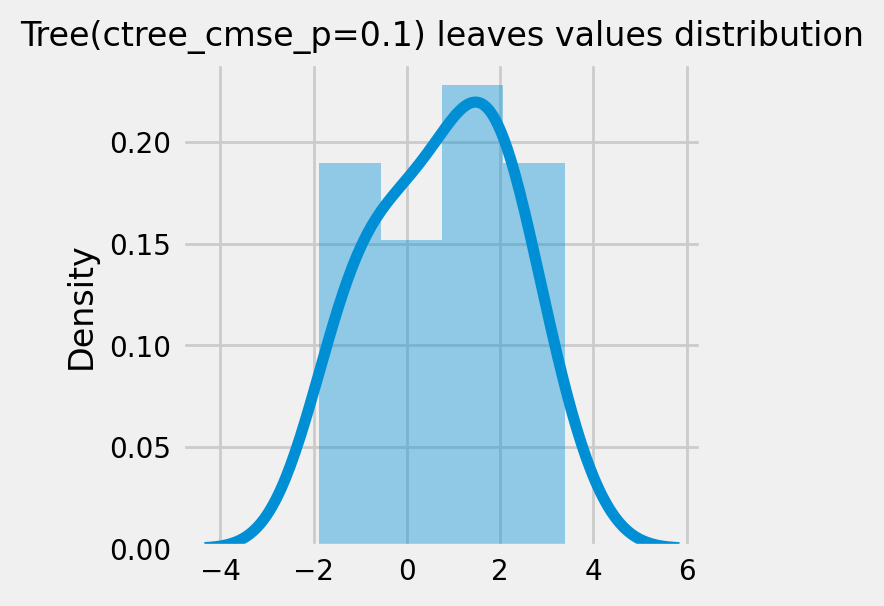

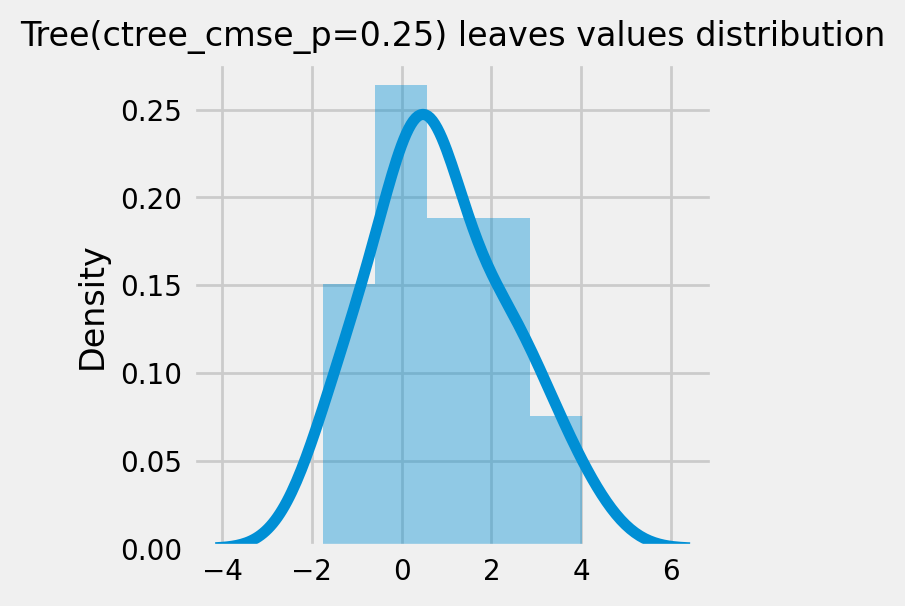

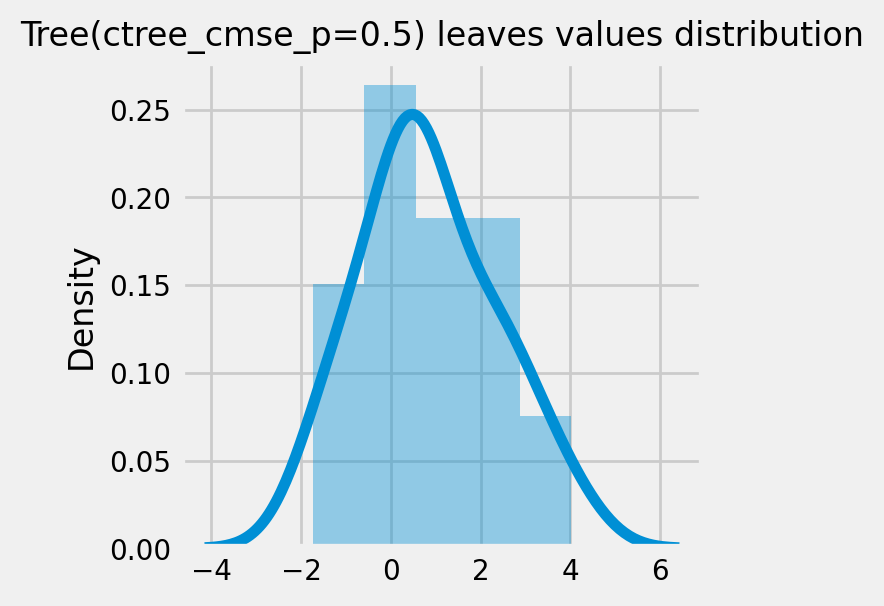

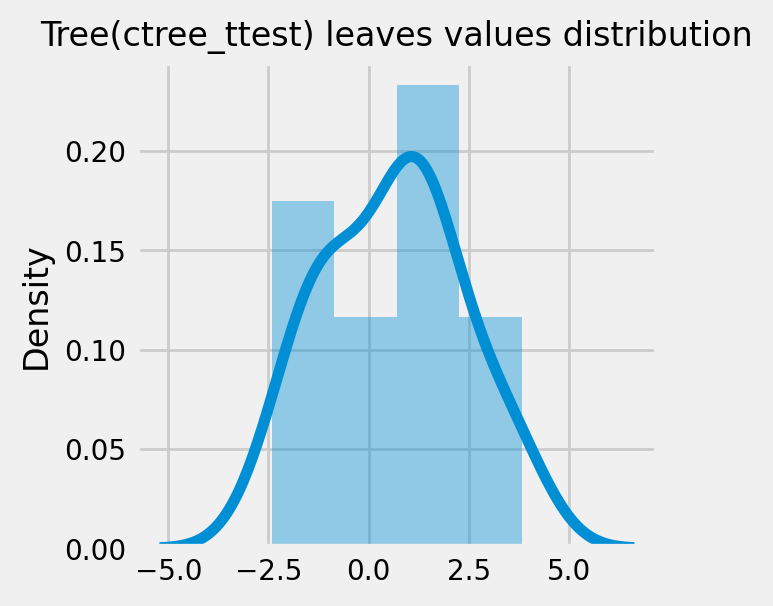

In [18]:
for ctree_name, ctree_info in ctrees.items():
    plot_dist_tree_leaves_values(ctree_info['model'], 
                                 figsize=(3,3),
                                 title=f'Tree({ctree_name}) leaves values distribution')

### CausalRandomForestRegressor 

In [19]:
cforests = {
    'cforest_mse': {
        'params':
        dict(criterion='standard_mse',
             control_name=0,
             min_impurity_decrease=0,
             min_samples_leaf=400,
             groups_penalty=0.,
             groups_cnt=True),
    },
    'cforest_cmse': {
        'params':
        dict(
            criterion='causal_mse',
            control_name=0,
            min_samples_leaf=400,
            groups_penalty=0.,
            groups_cnt=True
        ),
    },
    'cforest_cmse_p=0.5': {
        'params':
        dict(
            criterion='causal_mse',
            control_name=0,
            min_samples_leaf=400,
            groups_penalty=0.5,
            groups_cnt=True,
        ),
    },
    'cforest_cmse_p=0.5_md=3': {
        'params':
        dict(
            criterion='causal_mse',
            control_name=0,
            max_depth=3,
            min_samples_leaf=400,
            groups_penalty=0.5,
            groups_cnt=True,
        ),
    },
    'cforest_ttest': {
        'params':
        dict(criterion='t_test',
             control_name=0,
             min_samples_leaf=400,
             groups_penalty=0.,
             groups_cnt=True),
    },
}

In [20]:
%%time
# Model treatment effect
for cforest_name, cforest_info in cforests.items():
    print(f"Fitting: {cforest_name}")
    cforest = CausalRandomForestRegressor(**cforest_info['params'])
    cforest.fit(X=df_train[feature_names].values,
              treatment=df_train['treatment'].values,
              y=df_train['outcome'].values)
    
    cforests[cforest_name].update({'model': cforest})
    df_result[cforest_name] = cforest.predict(df_test[feature_names].values)

Fitting: cforest_mse
Fitting: cforest_cmse
Fitting: cforest_cmse_p=0.5
Fitting: cforest_cmse_p=0.5_md=3
Fitting: cforest_ttest
CPU times: user 1min 22s, sys: 210 ms, total: 1min 22s
Wall time: 1min 22s


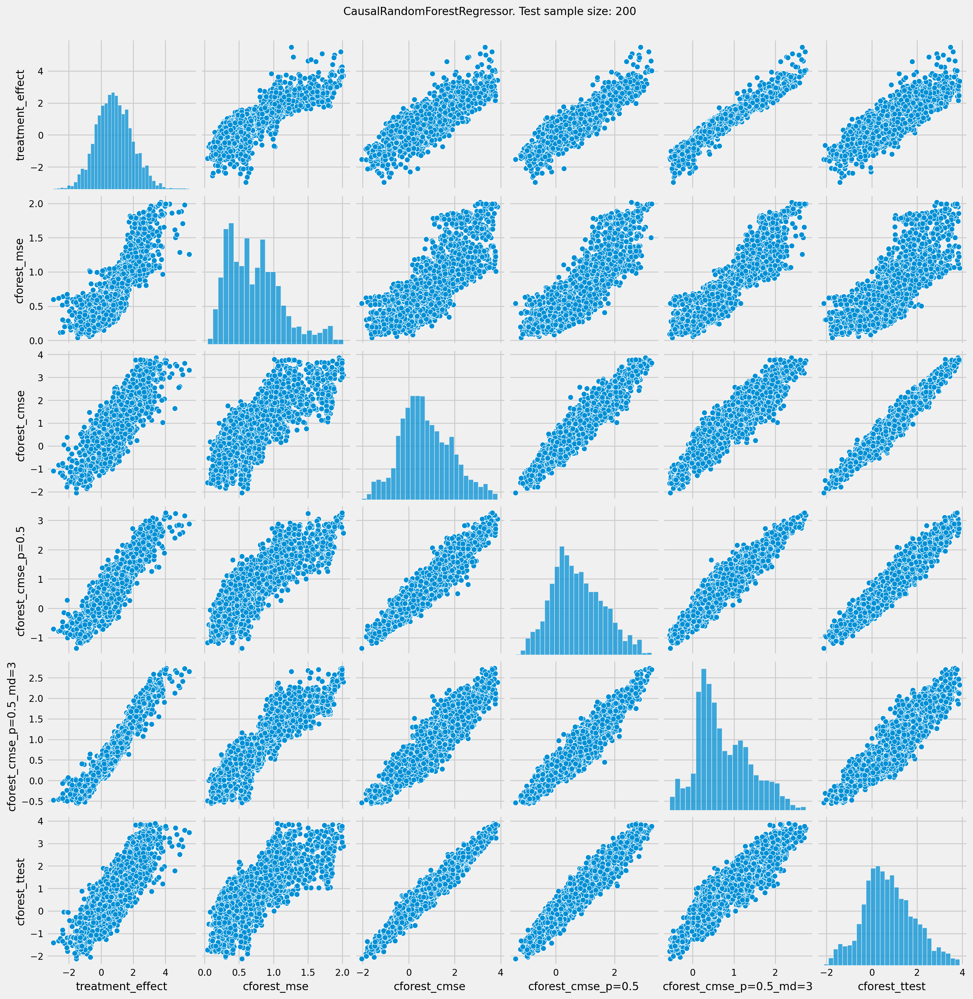

In [21]:
# See treatment effect estimation with CausalRandomForestRegressor vs true treatment effect 

n_obs = 200

indxs = df_result.index.values
np.random.shuffle(indxs)
indxs = indxs[:n_obs]

plt.rcParams.update({'font.size': 10})
pairplot = sns.pairplot(df_result[['treatment_effect', *list(cforests)]])
pairplot.fig.suptitle(f"CausalRandomForestRegressor. Test sample size: {n_obs}" , y=1.02)
plt.show()

In [22]:
df_qini = qini_score(df_result,
           outcome_col='outcome',
           treatment_col='is_treated',
           treatment_effect_col='treatment_effect')

df_qini.sort_values(ascending=False)

cforest_cmse_p=0.5_md=3    0.379258
cforest_cmse_p=0.5         0.346917
cforest_mse                0.332343
cforest_ttest              0.327512
cforest_cmse               0.323525
ctree_cmse_p=0.1           0.259049
ctree_cmse_p=0.25          0.230985
ctree_cmse_p=0.5           0.230985
ctree_cmse                 0.221881
ctree_mse                  0.217035
ctree_ttest                0.204657
Random                     0.000000
dtype: float64

#### Qini chart

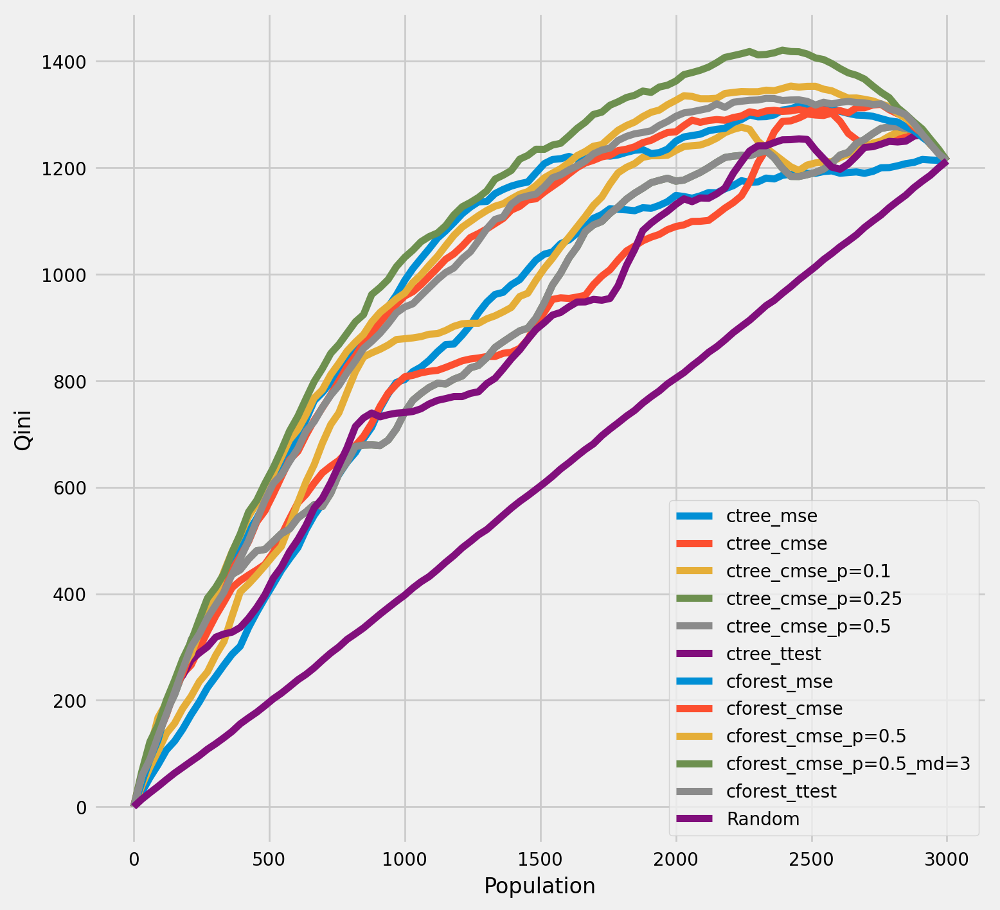

In [23]:
plot_qini(df_result,
          outcome_col='outcome',
          treatment_col='is_treated',
          treatment_effect_col='treatment_effect',
          figsize=(8,8)
         )

In [24]:
df_qini = qini_score(df_result,
           outcome_col='outcome',
           treatment_col='is_treated',
           treatment_effect_col='treatment_effect')

df_qini.sort_values(ascending=False)

cforest_cmse_p=0.5_md=3    0.379258
cforest_cmse_p=0.5         0.346917
cforest_mse                0.332343
cforest_ttest              0.327512
cforest_cmse               0.323525
ctree_cmse_p=0.1           0.259049
ctree_cmse_p=0.25          0.230985
ctree_cmse_p=0.5           0.230985
ctree_cmse                 0.221881
ctree_mse                  0.217035
ctree_ttest                0.204657
Random                     0.000000
dtype: float64

#### The cumulative gain of the true treatment effect in each population

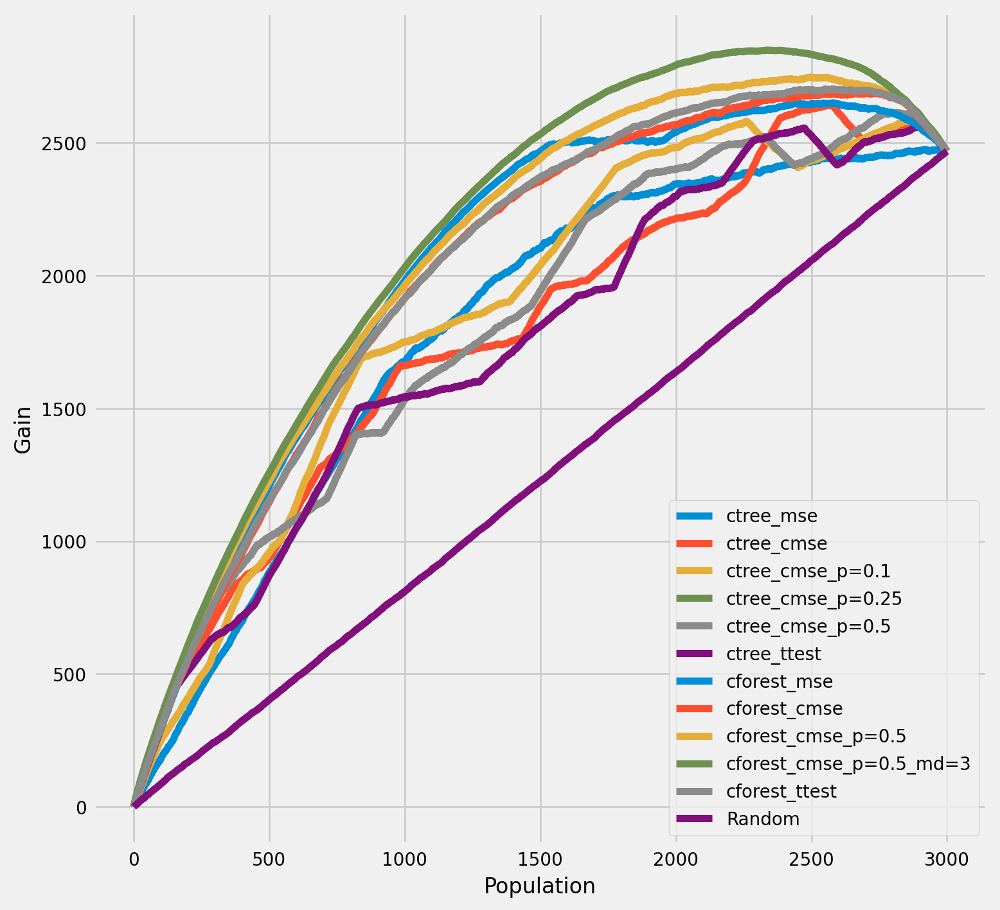

In [25]:
plot_gain(df_result, 
          outcome_col='outcome', 
          treatment_col='is_treated',
          treatment_effect_col='treatment_effect',
          n = n_test
         )

#### The cumulative difference between the mean outcomes of the treatment and control groups in each population

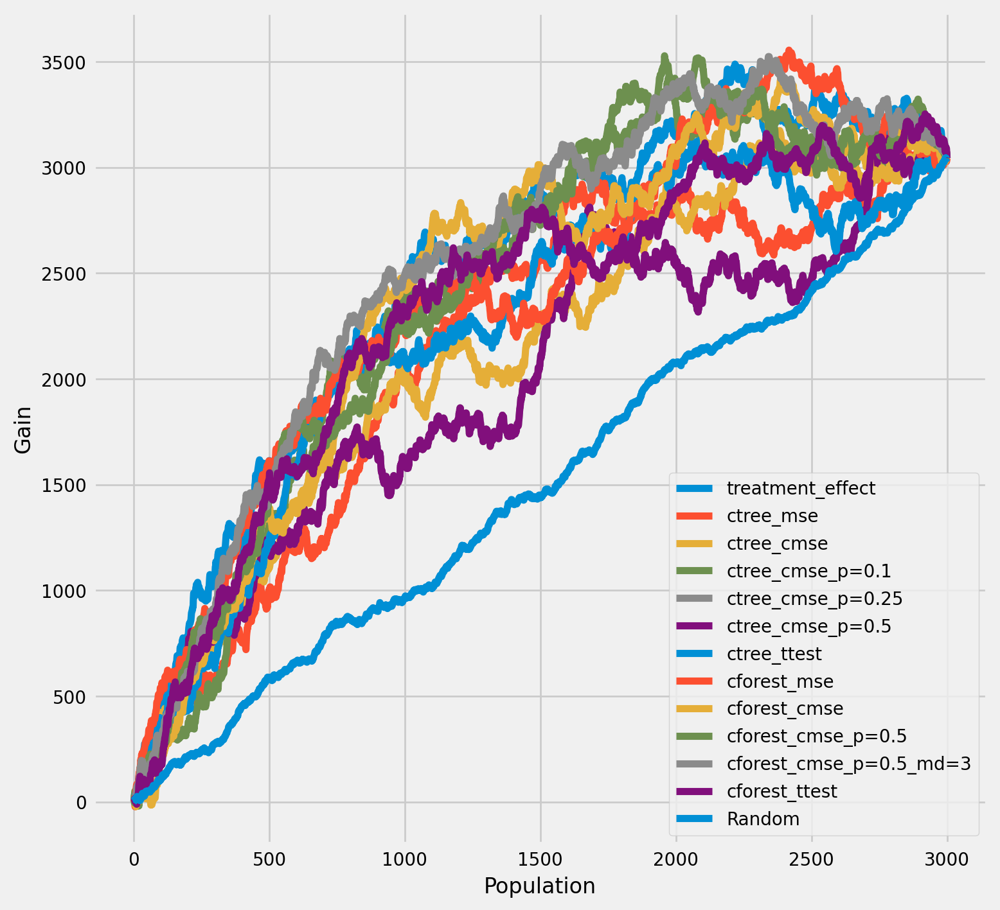

In [26]:
plot_gain(df_result, 
          outcome_col='outcome', 
          treatment_col='is_treated',
          n = n_test
         )

###  Meta-Learner Algorithms

In [27]:
X_train = df_train[feature_names].values
X_test = df_test[feature_names].values

# learner - DecisionTreeRegressor
# treatment learner - LinearRegression()

learner_x = BaseXRegressor(learner=DecisionTreeRegressor(), 
                           treatment_effect_learner=LinearRegression())
learner_s = BaseSRegressor(learner=DecisionTreeRegressor())
learner_t = BaseTRegressor(learner=DecisionTreeRegressor(), 
                           treatment_learner=LinearRegression())
learner_dr = BaseDRRegressor(learner=DecisionTreeRegressor(), 
                             treatment_effect_learner=LinearRegression())

learner_x.fit(X=X_train, treatment=df_train['treatment'].values, y=df_train['outcome'].values)
learner_s.fit(X=X_train, treatment=df_train['treatment'].values, y=df_train['outcome'].values)
learner_t.fit(X=X_train, treatment=df_train['treatment'].values, y=df_train['outcome'].values)
learner_dr.fit(X=X_train, treatment=df_train['treatment'].values, y=df_train['outcome'].values)

df_result['learner_x_ite'] = learner_x.predict(X_test)
df_result['learner_s_ite'] = learner_s.predict(X_test)
df_result['learner_t_ite'] = learner_t.predict(X_test)
df_result['learner_dr_ite'] = learner_dr.predict(X_test)

In [28]:
cate_dr = learner_dr.predict(X)
cate_x = learner_x.predict(X)
cate_s = learner_s.predict(X)
cate_t = learner_t.predict(X)

cate_ctrees = [info['model'].predict(X) for _, info in ctrees.items()]
cate_cforests = [info['model'].predict(X) for _, info in cforests.items()]

model_cate = [
    *cate_ctrees,
    *cate_cforests,
    cate_x, cate_s, cate_t, cate_dr
]

model_names = [
    *list(ctrees), *list(cforests),
    'X Learner', 'S Learner', 'T Learner', 'DR Learner']

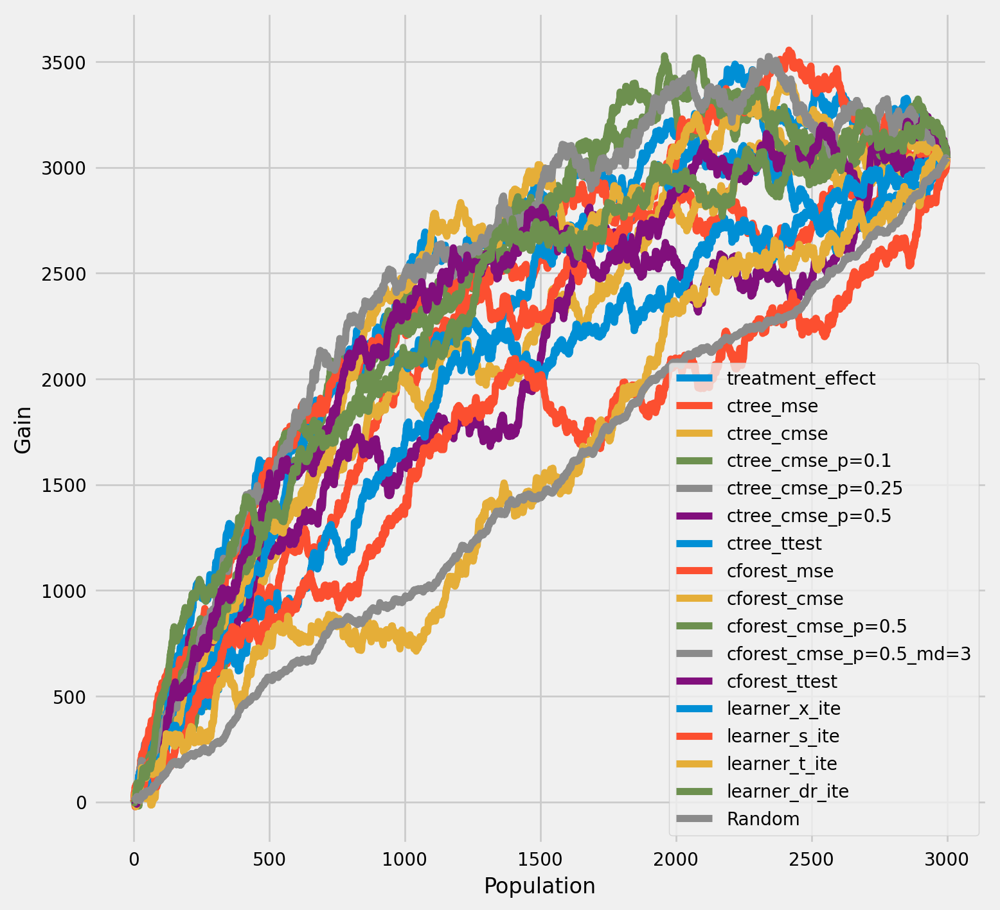

In [29]:
plot_gain(df_result, 
          outcome_col='outcome', 
          treatment_col='is_treated',
          n = n_test
         )

In [30]:
rows = 2
cols = 7
row_idxs = np.arange(rows)
col_idxs = np.arange(cols)

ax_idxs = np.dstack(np.meshgrid(col_idxs, row_idxs)).reshape(-1, 2) 

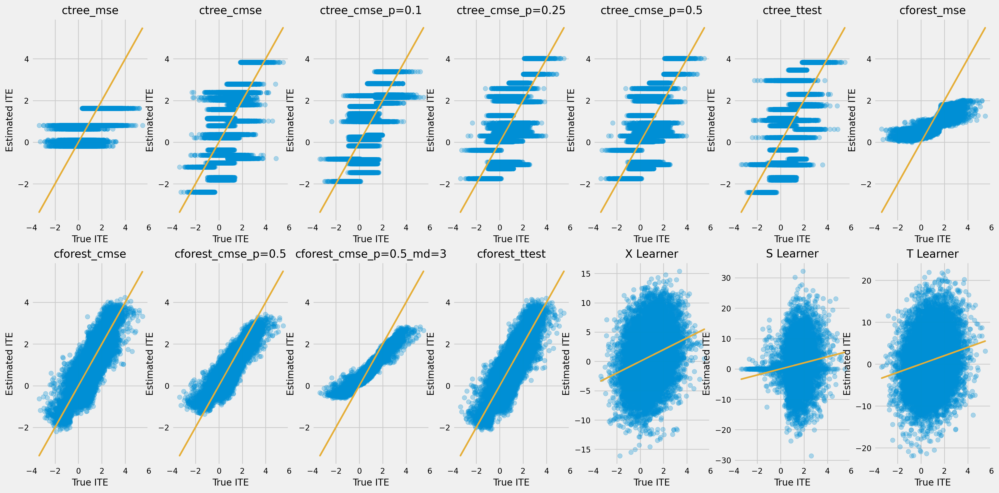

In [31]:
fig, ax = plt.subplots(rows, cols, figsize=(20, 10))
plt.rcParams.update({'font.size': 10})

for ax_idx, cate, model_name in zip(ax_idxs, model_cate, model_names):
    col_id, row_id = ax_idx
    cur_ax = ax[row_id, col_id]
    cur_ax.scatter(tau, cate, alpha=0.3)
    cur_ax.plot(tau, tau, color='C2', linewidth=2)
    cur_ax.set_xlabel('True ITE')
    cur_ax.set_ylabel('Estimated ITE')
    cur_ax.set_title(model_name)
    cur_ax.set_xlim((-4, 6))

#### The cumulative difference between the mean outcomes of the treatment and control groups in each population

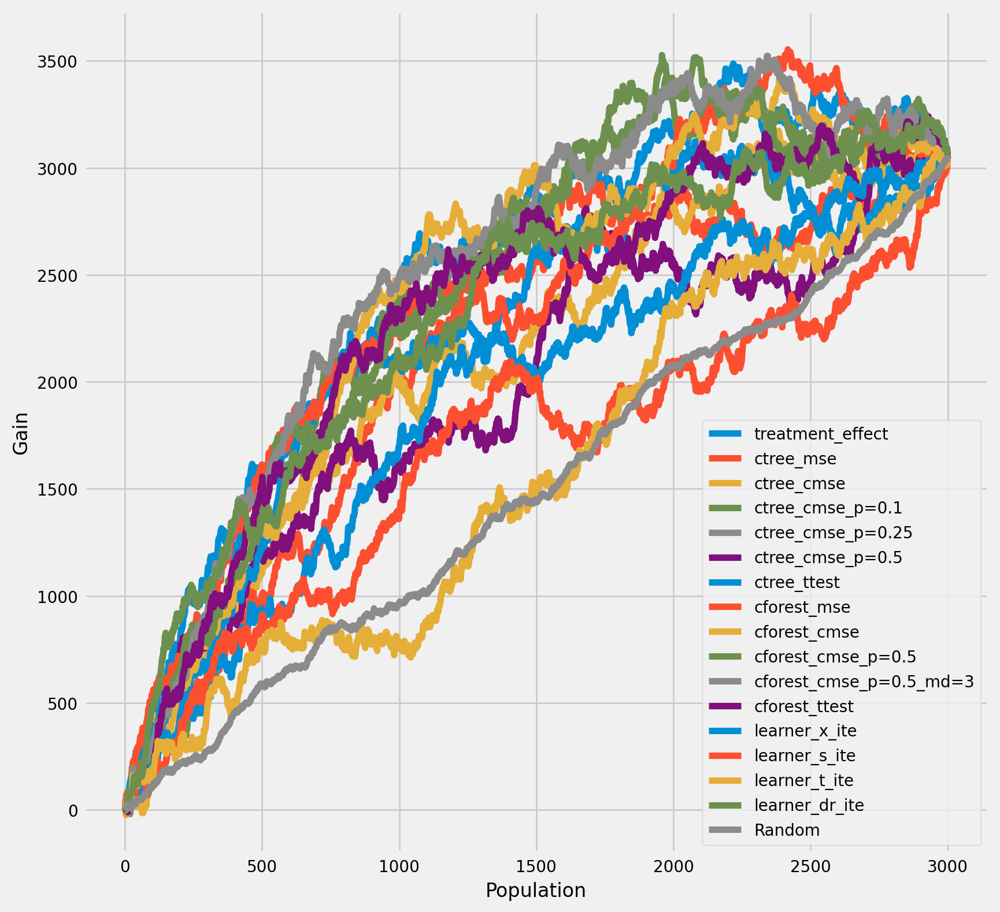

In [32]:
plot_gain(df_result, 
          outcome_col='outcome', 
          treatment_col='is_treated',
          n = n_test,
          figsize=(9, 9),
         )

#### Qini chart

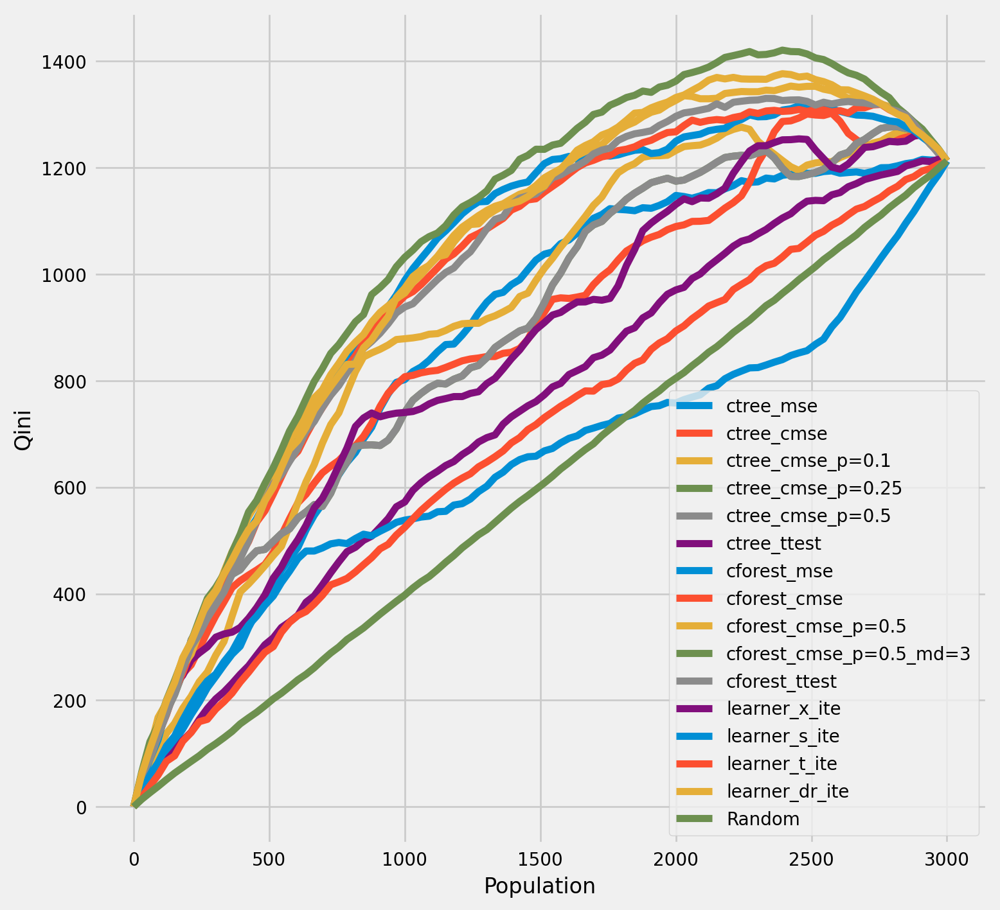

In [33]:
plot_qini(df_result,
          outcome_col='outcome',
          treatment_col='is_treated',
          treatment_effect_col='treatment_effect',
         )

In [34]:
df_qini = qini_score(df_result,
           outcome_col='outcome',
           treatment_col='is_treated',
           treatment_effect_col='treatment_effect')
df_qini.sort_values(ascending=False)

cforest_cmse_p=0.5_md=3    0.379258
learner_dr_ite             0.347385
cforest_cmse_p=0.5         0.346917
cforest_mse                0.332343
cforest_ttest              0.327512
cforest_cmse               0.323525
ctree_cmse_p=0.1           0.259049
ctree_cmse_p=0.25          0.230985
ctree_cmse_p=0.5           0.230985
ctree_cmse                 0.221881
ctree_mse                  0.217035
ctree_ttest                0.204657
learner_x_ite              0.106225
learner_t_ite              0.070401
learner_s_ite              0.031345
Random                     0.000000
dtype: float64

---

### Return outcomes along with estimated treatment effects

In [35]:
ctree_outcomes = ctrees["ctree_mse"]["model"].predict(X_test, with_outcomes=True)
df_ctree_outcomes = pd.DataFrame(ctree_outcomes, columns=["Y0", "Y1", "ITE"])
df_ctree_outcomes.head()

,Y0,Y1,ITE
0,0.770480,2.394923,1.624443
1,1.773314,2.582551,0.809237
2,0.770480,2.394923,1.624443
3,1.773314,2.582551,0.809237
4,1.773314,2.582551,0.809237


In [36]:
cforest_outcomes = cforests["cforest_mse"]["model"].predict(X_test, with_outcomes=True)
df_cforest_outcomes = pd.DataFrame(cforest_outcomes, columns=["Y0", "Y1", "ITE"])
df_cforest_outcomes.head()

,Y0,Y1,ITE
0,0.556832,1.309532,0.752699
1,1.851487,2.501465,0.649977
2,1.119464,2.596253,1.476789
3,1.664888,2.316147,0.651259
4,1.806281,2.544867,0.738587


### Bootstrap confidence intervals for individual treatment effects

In [37]:
alpha=0.05
tree = CausalTreeRegressor(criterion='causal_mse', control_name=0, min_samples_leaf=200, alpha=alpha)

In [38]:
# For time measurements
for n_jobs in (4, mp.cpu_count() - 1):
    for n_bootstraps in (10, 50, 100):
        print(f"n_jobs: {n_jobs} n_bootstraps: {n_bootstraps}" )
        tree.bootstrap_pool(
            X=X,
            treatment=w,
            y=y,
            n_bootstraps=n_bootstraps,
            bootstrap_size=10000,
            n_jobs=n_jobs,
            verbose=False
        )

n_jobs: 4 n_bootstraps: 10


100%|██████████| 10/10 [00:00<00:00, 14.05it/s]

Function: bootstrap_pool Kwargs: {'n_bootstraps': 10, 'bootstrap_size': 10000, 'n_jobs': 4, 'verbose': False} Elapsed time: 0.8112
n_jobs: 4 n_bootstraps: 50



100%|██████████| 50/50 [00:02<00:00, 17.20it/s]

Function: bootstrap_pool Kwargs: {'n_bootstraps': 50, 'bootstrap_size': 10000, 'n_jobs': 4, 'verbose': False} Elapsed time: 2.9469
n_jobs: 4 n_bootstraps: 100


...

Function: bootstrap_pool Kwargs: {'n_bootstraps': 10, 'bootstrap_size': 10000, 'n_jobs': 7, 'verbose': False} Elapsed time: 0.5142
n_jobs: 7 n_bootstraps: 50



100%|██████████| 50/50 [00:02<00:00, 23.35it/s]

Function: bootstrap_pool Kwargs: {'n_bootstraps': 50, 'bootstrap_size': 10000, 'n_jobs': 7, 'verbose': False} Elapsed time: 2.1945
n_jobs: 7 n_bootstraps: 100



100%|██████████| 100/100 [00:04<00:00, 21.18it/s]

Function: bootstrap_pool Kwargs: {'n_bootstraps': 100, 'bootstrap_size': 10000, 'n_jobs': 7, 'verbose': False} Elapsed time: 4.7802


In [39]:
te, te_lower, te_upper = tree.fit_predict(
        X=df_train[feature_names].values,
        treatment=df_train["treatment"].values,
        y=df_train["outcome"].values,
        return_ci=True,
        n_bootstraps=500,
        bootstrap_size=5000,
        n_jobs=mp.cpu_count() - 1,
        verbose=False)

100%|██████████| 500/500 [00:08<00:00, 57.93it/s]


Function: bootstrap_pool Kwargs: {'n_bootstraps': 500, 'bootstrap_size': 5000, 'n_jobs': 7, 'verbose': False} Elapsed time: 8.6945


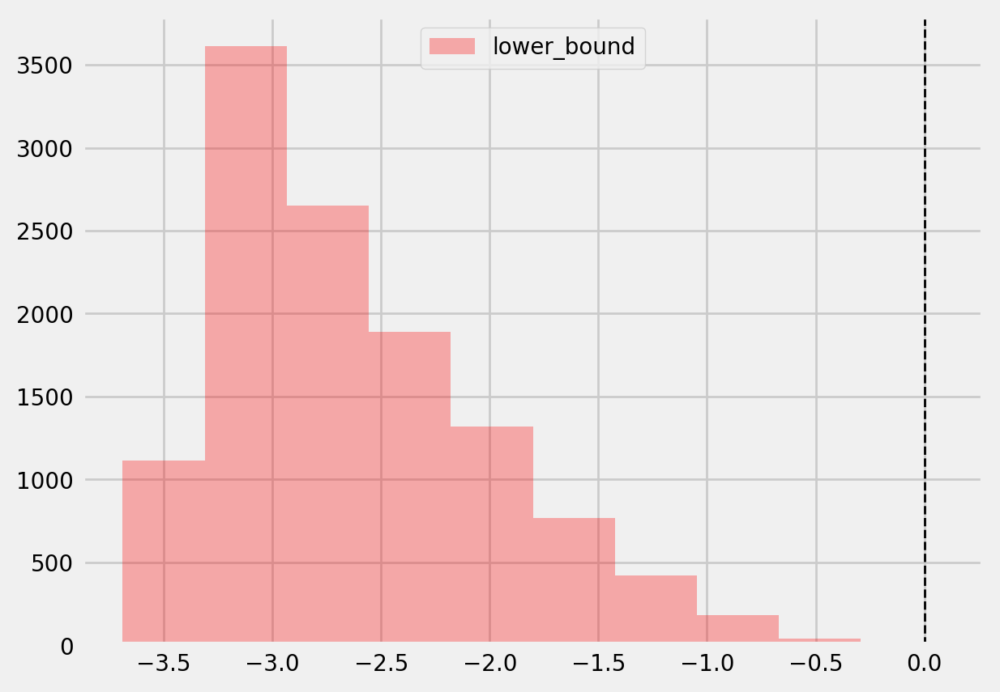

In [40]:
plt.hist(te_lower, color='red', alpha=0.3, label='lower_bound')
plt.axvline(x = 0, color = 'black', linestyle='--', lw=1, label='')
plt.legend()
plt.show()

In [41]:
# Significant estimates for negative and positive individual effects
# Default alpha = 0.05

bootstrap_neg = te[(te_lower < 0) & (te_upper < 0)]
bootstrap_pos = te[(te_lower > 0) & (te_upper > 0)]
print(bootstrap_neg.shape, bootstrap_pos.shape)

(0,) (3,)


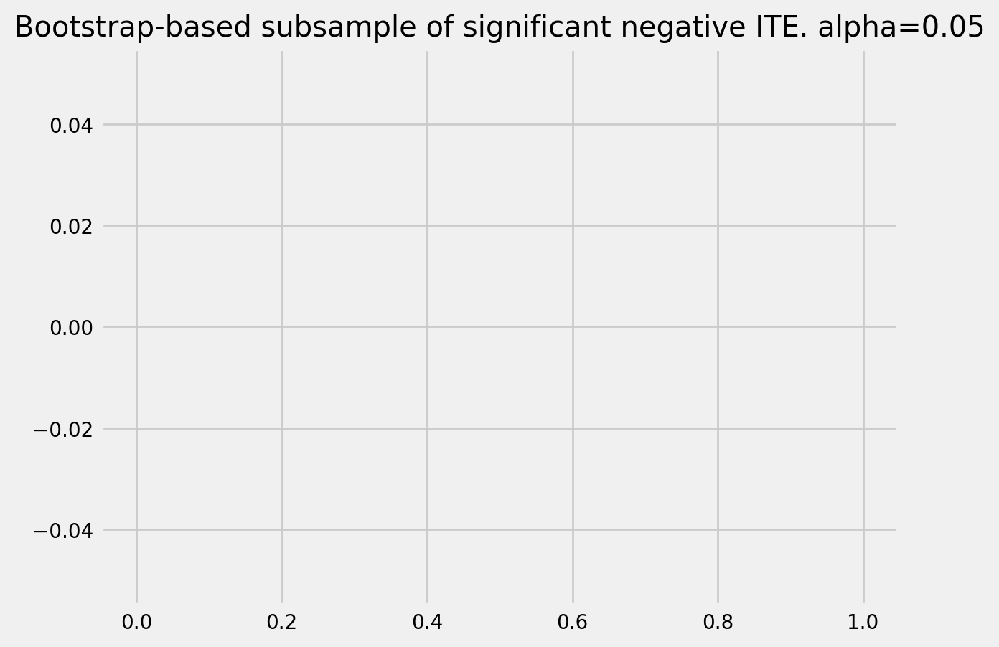

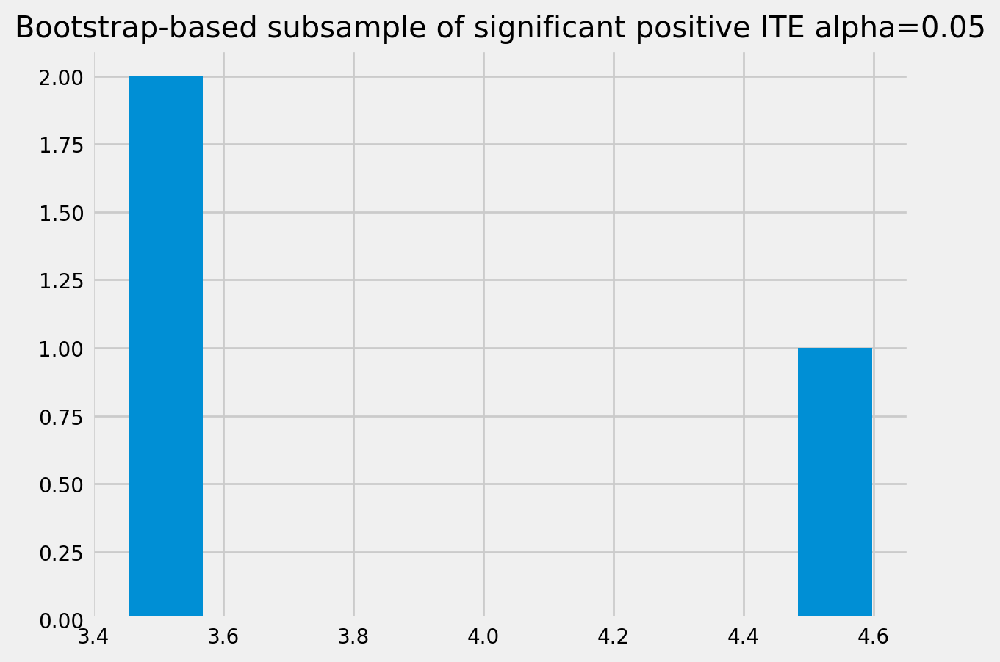

In [42]:
plt.hist(bootstrap_neg)
plt.title(f'Bootstrap-based subsample of significant negative ITE. alpha={alpha}')
plt.show()

plt.hist(bootstrap_pos)
plt.title(f'Bootstrap-based subsample of significant positive ITE alpha={alpha}')
plt.show()

### Average treatment effect

In [43]:
tree = CausalTreeRegressor(criterion='causal_mse', control_name=0, min_samples_leaf=200, alpha=alpha)
te, te_lb, te_ub = tree.estimate_ate(X=X, treatment=w, y=y)
print('ATE:', te, 'Bounds:', (te_lb, te_ub ), 'alpha:', alpha)

ATE: 0.8087131266584444 Bounds: (0.8084641289076601, 0.8089621244092288) alpha: 0.05


### CausalRandomForestRegressor ITE std

In [44]:
%%time
crforest = CausalRandomForestRegressor(criterion="causal_mse",  min_samples_leaf=200,
                                       control_name=0, n_estimators=50, n_jobs=mp.cpu_count()-1)
crforest.fit(X=df_train[feature_names].values,
             treatment=df_train['treatment'].values,
             y=df_train['outcome'].values
             )

CPU times: user 17.5 s, sys: 148 ms, total: 17.7 s
Wall time: 4.32 s


CausalRandomForestRegressor(min_samples_leaf=200, n_estimators=50, n_jobs=7)

In [45]:
crforest_te_pred = crforest.predict(df_test[feature_names])
crforest_test_var = crforest.calculate_error(X_train=df_train[feature_names].values,
                                        X_test=df_test[feature_names].values)
crforest_test_std = np.sqrt(crforest_test_var)

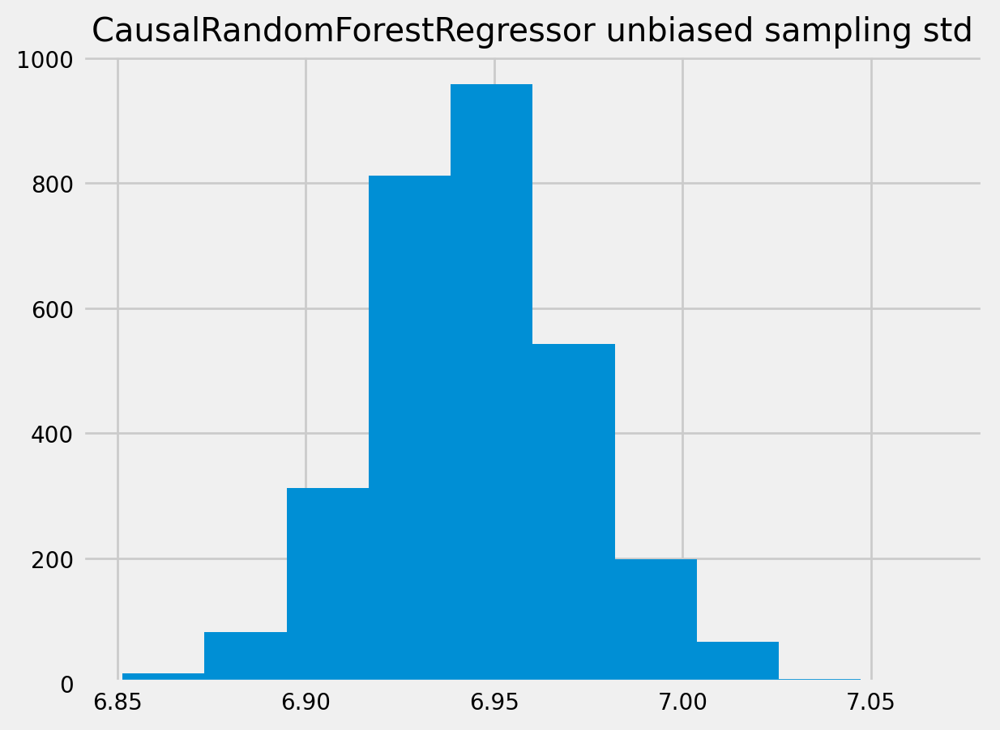

In [46]:
plt.hist(crforest_test_std)
plt.title("CausalRandomForestRegressor unbiased sampling std")
plt.show()